<a href="https://colab.research.google.com/github/PSHUniHub/Algorithm-LetUsGraduate/blob/main/%EC%B5%9C%EC%A2%85%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

# 1. 드라이브 연결
drive.mount('/content/drive', force_remount=True)

# 2. 정확한 경로 지정 (공백이나 오타 주의)
notebook_path = '/content/drive/My Drive/알고리즘/알고리즘 기능통합'

if os.path.exists(notebook_path):
    os.chdir(notebook_path)
    print("✅ 연결 성공! 현재 위치:", os.getcwd())
    print("📁 현재 폴더 안의 파일들:", os.listdir())
else:
    print("❌ 경로를 찾을 수 없습니다. 구글 드라이브의 폴더명을 다시 확인해주세요.")

Mounted at /content/drive
✅ 연결 성공! 현재 위치: /content/drive/My Drive/알고리즘/알고리즘 기능통합
📁 현재 폴더 안의 파일들: ['accepted_spec.csv', '최종본', 'CSS', 'company_requirements.csv', 'index.html', 'app.py', 'subjects.csv']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pkill -9 -f ngrok
!pkill -9 -f app.py


In [ ]:
# 구글 드라이브의 파일들을 코랩 기본 실행 경로(/content)로 강제 복사하기
!cp -r "/content/drive/My Drive/알고리즘/알고리즘 기능통합/"* /content/

print("코랩 기본 폴더 복사 완료! 이제 아래 서버 구동 셀을 실행해 보세요.")

코랩 기본 폴더 복사 완료! 이제 아래 서버 구동 셀을 실행해 보세요.


여기 밑에 두개 셀 실행하시고 마지막 셀 링크 들어가신다음에 IP 넣으시고 이동하시면 됩니다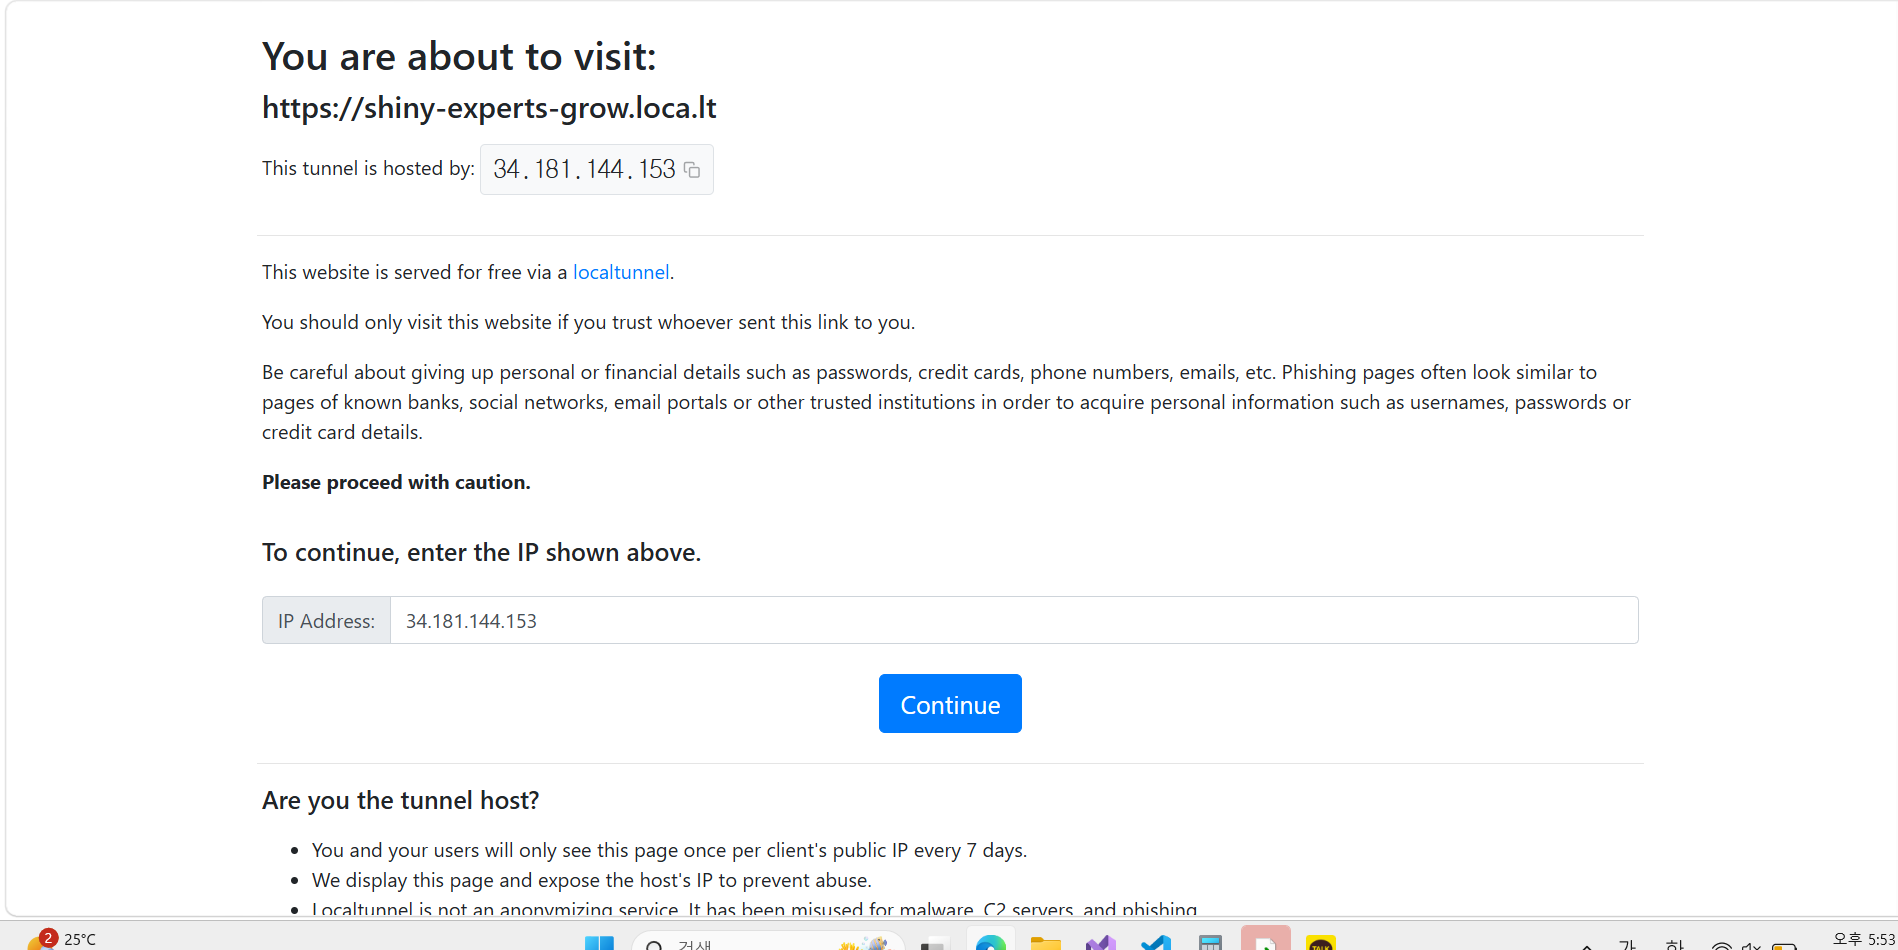

In [ ]:
# =================================================================
# 0. 백엔드 및 ngrok 프로세스 강제 완전 초기화
# =================================================================
print("🧹 안전하고 깨끗한 가동을 위해 백엔드 및 ngrok 프로세스를 완전 초기화합니다...")
import os
import time
import subprocess

os.system("pkill -9 -f 'app.py'")
os.system("pkill -9 -f 'ngrok'")

try:
    port_pid = subprocess.check_output("lsof -t -i:9985", shell=True).decode('utf-8').strip()
    if port_pid:
        for pid in port_pid.split('\n'):
            os.system(f"kill -9 {pid}")
        print("🔓 점유 중이던 9985 포트를 강제로 해제했습니다.")
except Exception:
    pass

print("📦 필수 라이브러리 검증 및 의존성 패키지 설치...")
!pip install -q pyngrok flask Flask-Cors pandas

from pyngrok import ngrok, process
try:
    ngrok.kill()
    process._process_objects.clear()
except Exception:
    pass
time.sleep(1.5)

# =================================================================
# 1. 실제 파일 경로 설정
# =================================================================

TARGET_DIR = "/content"

app_py_path = "/content/app.py"
index_html_path = "/content/index.html"
style_css_path = "/content/css/style.css"

app_py_path = os.path.join(TARGET_DIR, "app.py")
index_html_path = os.path.join(TARGET_DIR, "index.html")

# CSS는 sample_data 안이 아니라 /content/CSS
style_css_path = "/content/CSS/style.css"

print("🔍 파일 상태 확인")

print("app.py :", os.path.exists(app_py_path))
print("index.html :", os.path.exists(index_html_path))
print("style.css :", os.path.exists(style_css_path))

# =================================================================
# ⚙️ [실시간 핫패치] 수동 업로드된 app.py 내부의 CSS 경로 버그 정밀 수정
# =================================================================
# 사용자가 직접 업로드한 app.py를 읽어서 CSS 라우팅 엔드포인트가 정밀 작동하도록 코드를 교정합니다.
if os.path.exists(app_py_path):
    print("🛠️ 업로드된 app.py의 정적 파일(CSS) 라우팅 호환성을 강화하는 패치를 적용 중...")
    with open(app_py_path, "r", encoding="utf-8") as f:
        app_content = f.read()

    # Flask 서버 내부에서 /CSS/style.css 호출 시 정상 반환할 수 있도록 라우터 강제 주입/수정
    css_route_code = """
@app.route('/CSS/style.css')
def serve_css_patched():
    from flask import send_file
    return send_file('/content/CSS/style.css', mimetype='text/css')
"""
    if "@/CSS/style.css" not in app_content and "serve_css" not in app_content:
        # app.run 실행 바로 직전에 라우터 함수 가로채기 주입
        if "if __name__" in app_content:
            app_content = app_content.replace("if __name__", css_route_code + "\nif __name__")
        else:
            app_content += "\n" + css_route_code

    with open(app_py_path, "w", encoding="utf-8") as f:
        f.write(app_content)
    print("⚡ app.py 디자인 서빙 패치 완료!")

print("🚀 준비 완료! 패치 및 배치된 실제 서비스 파일들로 서버 구동을 시작합니다...")

# =================================================================
# 2. 백엔드 인프라 서버 프로세스 독립 구동
# =================================================================
import subprocess
subprocess.Popen(
    ["python3", app_py_path]
)
time.sleep(2.5)
print("✅ 백엔드 코어가 정상 가동 중입니다.")

# =================================================================
# 3. ngrok 터널 라우팅 개통 및 외부 접속 주소 출력
# =================================================================
NGROK_TOKEN = "3EqKm9QnrwQZ65hLZg12JY0MJ7I_3occ8y6kbc2NbAz99W4VP"
ngrok.set_auth_token(NGROK_TOKEN)

try:
    public_url = ngrok.connect(9985)
    print("\n==================================================")
    print("✨🎉 [4개 전 기능 통합 최종 포탈 빌드 완결] 🎉✨")
    print("==================================================")
    print("👉 아래 발급된 안전 웹 주소로 즉시 접속하세요:")
    print(f"🔗 {public_url.public_url}")
    print("==================================================\n")
except Exception as e:
    print(f"🚨 ngrok 연결 실패 원인: {e}")

print("✅ 서버 실행 완료")
print("\n🛑 시스템 인프라 서빙이 안전하게 종료되었습니다.")

🧹 안전하고 깨끗한 가동을 위해 백엔드 및 ngrok 프로세스를 완전 초기화합니다...
📦 필수 라이브러리 검증 및 의존성 패키지 설치...
🔍 파일 상태 확인
app.py : True
index.html : True
style.css : True
🛠️ 업로드된 app.py의 정적 파일(CSS) 라우팅 호환성을 강화하는 패치를 적용 중...
⚡ app.py 디자인 서빙 패치 완료!
🚀 준비 완료! 패치 및 배치된 실제 서비스 파일들로 서버 구동을 시작합니다...
✅ 백엔드 코어가 정상 가동 중입니다.

✨🎉 [4개 전 기능 통합 최종 포탈 빌드 완결] 🎉✨
👉 아래 발급된 안전 웹 주소로 즉시 접속하세요:
🔗 https://requisite-cancel-ravioli.ngrok-free.dev

✅ 서버 실행 완료

🛑 시스템 인프라 서빙이 안전하게 종료되었습니다.


In [ ]:
# 1. 로컬터널 패키지 설치
!npm install -g localtunnel

# 2. Flask가 9985 포트로 켜져 있는 상태에서 아래 명령어 실행 (뒤에 & 필수)
!lt --port 9985 &

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 4s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇your url is: https://chubby-parts-march.loca.lt
